In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2)

import conf.dataset
from conf import conf
from g_led import main_sequential, datasets, models, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [21]:
# special "runs"
TRUE_RUN = 'True'
runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label', 'ckpt_filename', 'special',
    ],
    data=[
        [TRUE_RUN, 'True', '', True],
        ['rj700zkc', '59,9', 'saved_for_plotting_epoch_59__forecast_time_step_count_9.ckpt', False],
        ['rj700zkc', '217,91', 'epoch_217__forecast_time_step_count_91.ckpt', False],
    ]
).with_columns(key=pl.int_range(pl.len()).cast(str))
def iter_runs(include_special=False, **kwargs):
    if 'named' not in kwargs:
        kwargs['named'] = True
    for row in runs.iter_rows(**kwargs):
        if include_special or not row['special']:
            yield row
runs

alt_id,label,ckpt_filename,special,key
str,str,str,bool,str
"""True""","""True""","""""",true,"""0"""
"""rj700zkc""","""59,9""","""saved_for_plotting_epoch_59__f…",false,"""1"""
"""rj700zkc""","""217,91""","""epoch_217__forecast_time_step_…",false,"""2"""


In [23]:
context = defaultdict(dict)
for run in iter_runs():
    with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
        cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
            'model=Trained',
            f"model.conf={run['alt_id']}",
            f"model.ckpt_filename={run['ckpt_filename']}",
            
            'dataset=Macro',
            'dataset.split=TRAIN',
            'dataset.batch_size_train=1',
            'dataset.batch_size_val=1',
            'dataset.initial_sequence_time_step_start=0',
            'dataset.initial_sequence_time_step_count=1',
            'dataset.forecast_time_step_count=150',
            
            'dataset@dataset.dataset=BackwardFacingStep2D',
            'dataset.dataset.batch_size_train=16',
            'dataset.dataset.batch_size_val=16',
            
            'model@dataset.model=Trained',
            f"dataset.model.conf={run['alt_id']}",
            f"dataset.model.ckpt_filename={run['ckpt_filename']}",
        ])
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        context[run['key']]['cfg'] = cfg
        
        lightning.pytorch.seed_everything(cfg.rng_seed)
        with lightning.pytorch.utilities.seed.isolate_rng():
            dataset = datasets.get_dataset(cfg.dataset)
            dataset.prepare_data()
            dataset.setup('predict')

        context[run['key']]['window_pred'] = dataset.trajectories_macro[:, cfg.dataset.initial_sequence_time_step_count:]
        

context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred'] = dataset.downsampler(
    dataset.trajectories_micro[:, cfg.dataset.initial_sequence_time_step_count:]
)

max_key_len = runs.select(pl.col('key').str.len_chars().max())['key'][0]
for run in iter_runs(include_special=True):
    if run['key'] in context:
        print(f"{run['key']}{':':<{max_key_len+1}}{context[run['key']]['window_pred'].shape}")

Seed set to 2376999025
Seed set to 2376999025


0: torch.Size([1, 150, 2, 32, 32])
1: torch.Size([1, 150, 2, 32, 32])
2: torch.Size([1, 150, 2, 32, 32])


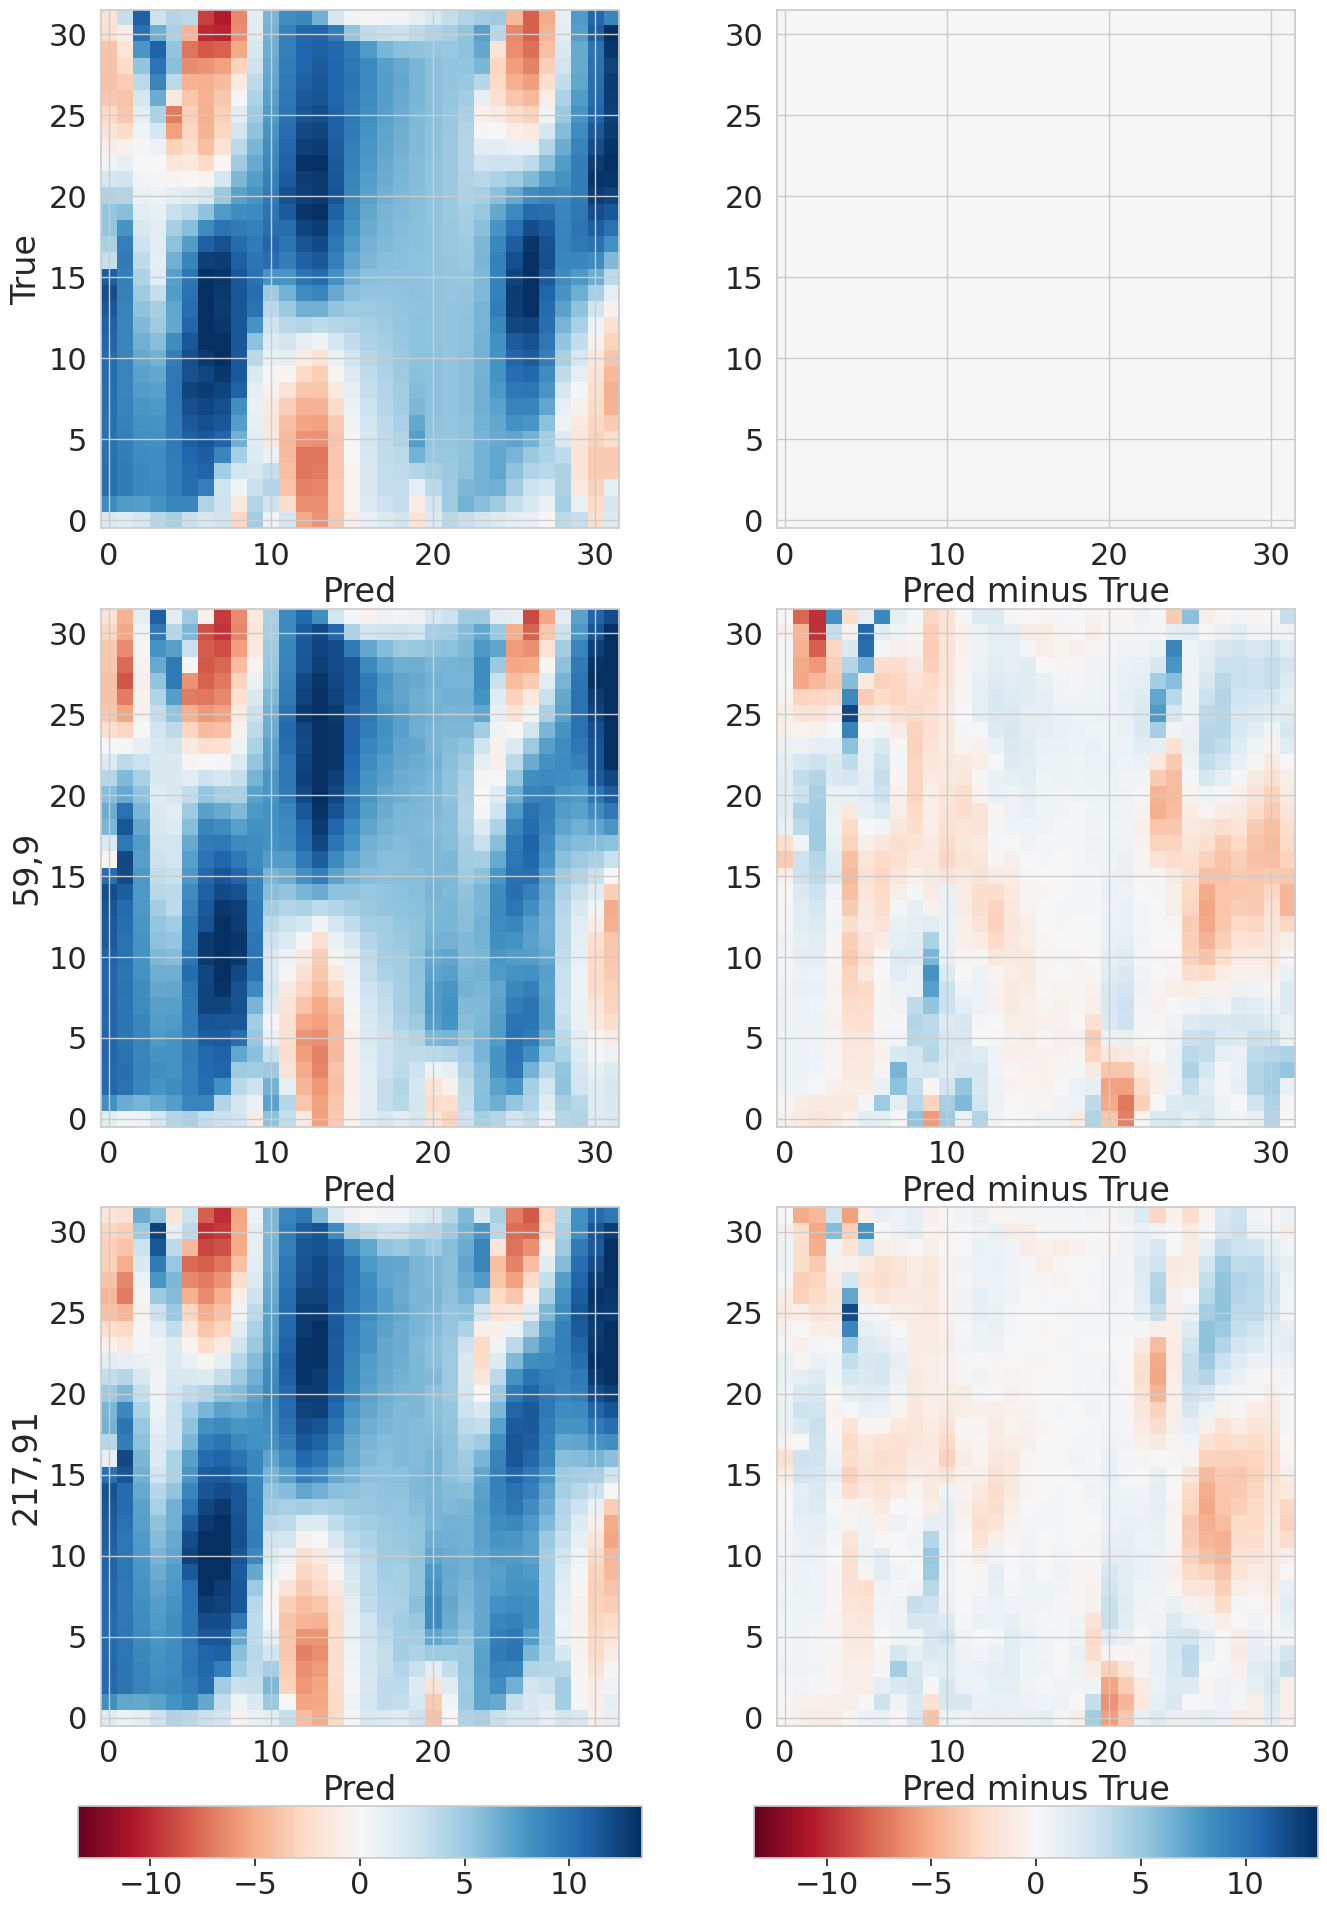

In [24]:
trajectory = 0
time_step = -1
component = 0

data_true = context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred'][trajectory, time_step, component]
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))

plot_cfgs = {
    k: context[k]['window_pred'][trajectory, time_step, component] for k in runs.get_column('key')
}
fig, axs = plt.subplots(figsize=(16, 6 + 6 * len(plot_cfgs)), nrows=len(plot_cfgs) + 1, ncols=2, height_ratios=[*([10] * len(plot_cfgs)), 1])
for axs_row, (k, data) in zip(axs, plot_cfgs.items()):
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    run = runs.filter(key=k)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(run['label'][0])
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')

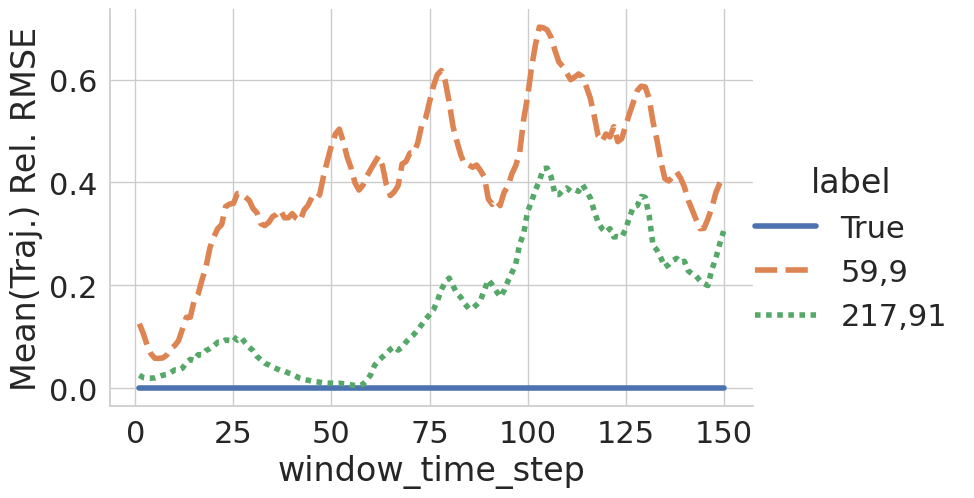

In [27]:
data_true = context[runs.filter(alt_id=TRUE_RUN)['key'][0]]['window_pred']
rel_rmses = {}
for k, v in context.items():
    data = v['window_pred'][0]
    rmse = reduce(
        (data - data_true).square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    norm = reduce(
        data_true.square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    rel_rmses[k] = (rmse / norm).mean(0).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(1, pl.len()+1))
# print(rel_rmses)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='key', value_name='Mean(Traj.) Rel. RMSE')
    .join(runs, on='key')
)
# print(plot_data)
row_order = runs.sort('key').get_column('label')
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='Mean(Traj.) Rel. RMSE',
        hue_order=row_order,
        style_order=row_order,
        hue='label',
        style='label',
        markers=data_true.shape[1] <= 100,
        linewidth=4,
        markersize=12,
        height=5.5,
        aspect=1.5,
    )
)